# Task 4: Variational Autoencoders
EE-5102/CS-6304 - Advanced Topics in Machine Learning - Programming Assignment 0

This notebook implements all subtasks of the VAE section:
1. Building a convolutional VAE for MNIST (3-layer conv encoder/decoder, reparameterization trick, ELBO loss, training)
2. Analyzing VAE performance (2D latent-space visualization, reconstruction quality, sample generation)
3. Comparing our implementation with Carl Doersch's tutorial VAE


## 0. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import random, os, time
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "../data"
WEIGHTS_DIR = "../weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# GPU info
print("Using device:", device)
if torch.cuda.is_available():
    print(f"Num GPUs: {torch.cuda.device_count()}")

    current_device = torch.cuda.current_device()
    print(f"Current Device Index: {current_device}")
    print(f"Device Name: {torch.cuda.get_device_name(current_device)}")

    props = torch.cuda.get_device_properties(current_device)
    print(f"Total Memory: {props.total_memory / 1e9:.2f} GB")
    print(f"CUDA Capability: {props.major}.{props.minor}")
else:
    print("PyTorch is currently using the CPU.")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Global plotting style -- matches Task 1 notebook (seaborn theme applied to every matplotlib figure)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"


Using device: cuda
Num GPUs: 1
Current Device Index: 0
Device Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Total Memory: 6.09 GB
CUDA Capability: 8.6


### Data: MNIST
We use the standard 28x28 grayscale MNIST digits, scaled to $[0, 1]$ (no further
normalization), since the decoder assumes a Bernoulli output distribution over pixel
intensities.

In [2]:
tfms = transforms.Compose([transforms.ToTensor()])  # already in [0, 1], no extra normalization

train_set = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=tfms)
test_set = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=tfms)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train set: {len(train_set)} images | Test set: {len(test_set)} images")


Train set: 60000 images | Test set: 10000 images


## 1. Building a Basic VAE in PyTorch

**Encoder** — a 3-layer convolutional network ($1\times28\times28 \to 32\times14\times14 \to 64\times7\times7 \to 128\times4\times4$, each `Conv2d` with stride 2 followed by `BatchNorm2d` and `LeakyReLU`), flattened and passed through a linear layer to produce the mean $\mu_\phi(x)$ and log-variance $\log\sigma_\phi^2(x)$ of the approximate posterior $q_\phi(z\mid x)$. The assignment explicitly allows either an MLP or a small convolutional network for the encoder/decoder; we use the convolutional option so the model can exploit the spatial structure of the digit strokes.

**Reparameterization trick** — sample $\epsilon \sim \mathcal{N}(0, I)$ and compute
$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon$, which keeps the sampling step
differentiable with respect to $\phi$.

**Decoder** — a linear layer projects $z$ back to a $128\times4\times4$ feature map, which then passes through 3 transposed-convolution layers that mirror the encoder ($128\times4\times4 \to 64\times7\times7 \to 32\times14\times14 \to 1\times28\times28$), producing logits over the 784 pixels; a sigmoid turns these into per-pixel Bernoulli probabilities $p_\theta(x \mid z)$.

We set the latent dimension to **2** so the latent space can be visualized directly without
any additional dimensionality reduction (Task 2a).

In [3]:
class ConvVAE(nn.Module):
    """3-layer convolutional VAE for 28x28 MNIST digits.

    Encoder: Conv2d x3 (stride-2 downsampling, 28 -> 14 -> 7 -> 4) -> FC(mu), FC(logvar)
    Decoder: FC -> ConvTranspose2d x3 (mirrored upsampling, 4 -> 7 -> 14 -> 28), outputs logits
    """

    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim

        # --- Encoder q_phi(z | x): 3 conv layers ---
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),    # 28x28 -> 14x14
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),   # 14x14 -> 7x7
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 7x7 -> 4x4
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
        )
        self.enc_feat_dim = 128 * 4 * 4
        self.enc_mu = nn.Linear(self.enc_feat_dim, latent_dim)
        self.enc_logvar = nn.Linear(self.enc_feat_dim, latent_dim)

        # --- Decoder p_theta(x | z): FC projection + 3 mirrored transposed-conv layers ---
        self.dec_fc = nn.Linear(latent_dim, self.enc_feat_dim)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),  # 4x4 -> 7x7
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),   # 7x7 -> 14x14
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),    # 14x14 -> 28x28
        )  # final layer outputs logits (sigmoid applied via BCEWithLogits, not inside the module)

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.enc_mu(h), self.enc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = self.dec_fc(z).view(-1, 128, 4, 4)
        return self.dec(h)  # logits, shape (B, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


LATENT_DIM = 2
vae = ConvVAE(latent_dim=LATENT_DIM).to(device)

n_params = sum(p.numel() for p in vae.parameters())
print(f"VAE parameters: {n_params:,}")
print(vae)


VAE parameters: 200,197
ConvVAE(
  (enc): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (enc_mu): Linear(in_features=2048, out_features=2, bias=True)
  (enc_logvar): Linear(in_features=2048, out_features=2, bias=True)
  (dec_fc): Linear(in_features=2, out_features=2048, bias=True)
  (dec): Sequential(
    (0): ConvTranspose2d(128, 64, kernel

**Loss (negative ELBO)** — the sum of a reconstruction term (binary cross-entropy between
the input and the decoder's output probabilities, i.e. $-\mathbb{E}_q[\log p_\theta(x\mid z)]$)
and the closed-form KL divergence between $\mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))$ and the
standard normal prior $\mathcal{N}(0, I)$:

$$D_{KL}\big(\mathcal{N}(\mu,\sigma^2) \,\|\, \mathcal{N}(0, I)\big)
= \frac{1}{2}\sum_{j=1}^{d}\big(\mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1\big).$$

In [4]:
def vae_loss(logits, x, mu, logvar):
    # reconstruction term: sum (not mean) over pixels, matching the standard MNIST-VAE convention
    recon_loss = F.binary_cross_entropy_with_logits(logits, x, reduction="sum")

    # closed-form KL divergence between q(z|x) and N(0, I)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss, recon_loss, kl_loss


### Training loop

In [11]:
def train_one_epoch(model, loader, optimizer, epoch, total_epochs):
    model.train()
    running_elbo, running_recon, running_kl, n_samples = 0.0, 0.0, 0.0, 0

    desc = f"Epoch {epoch}/{total_epochs} [Train]"
    pbar = tqdm(loader, desc=desc, leave=False)

    for imgs, _ in pbar:
        imgs = imgs.to(device)  # (B, 1, 28, 28) -- conv model consumes images directly, no flattening
        optimizer.zero_grad()

        logits, mu, logvar = model(imgs)
        loss, recon, kl = vae_loss(logits, imgs, mu, logvar)
        loss.backward()
        optimizer.step()

        running_elbo += loss.item()
        running_recon += recon.item()
        running_kl += kl.item()
        n_samples += imgs.size(0)

        pbar.set_postfix(elbo=f"{running_elbo / n_samples:.2f}")

    return running_elbo / n_samples, running_recon / n_samples, running_kl / n_samples


@torch.no_grad()
def evaluate(model, loader, epoch, total_epochs):
    model.eval()
    running_elbo, running_recon, running_kl, n_samples = 0.0, 0.0, 0.0, 0

    desc = f"Epoch {epoch}/{total_epochs} [Val]"
    pbar = tqdm(loader, desc=desc, leave=False)

    for imgs, _ in pbar:
        imgs = imgs.to(device)
        logits, mu, logvar = model(imgs)
        loss, recon, kl = vae_loss(logits, imgs, mu, logvar)

        running_elbo += loss.item()
        running_recon += recon.item()
        running_kl += kl.item()
        n_samples += imgs.size(0)

        pbar.set_postfix(elbo=f"{running_elbo / n_samples:.2f}")

    return running_elbo / n_samples, running_recon / n_samples, running_kl / n_samples


def run_training(model, train_loader, val_loader, epochs=50, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_elbo": [], "train_recon": [], "train_kl": [],
               "val_elbo": [], "val_recon": [], "val_kl": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        tr_elbo, tr_recon, tr_kl = train_one_epoch(model, train_loader, optimizer, epoch, epochs)
        val_elbo, val_recon, val_kl = evaluate(model, val_loader, epoch, epochs)

        history["train_elbo"].append(tr_elbo); history["train_recon"].append(tr_recon); history["train_kl"].append(tr_kl)
        history["val_elbo"].append(val_elbo); history["val_recon"].append(val_recon); history["val_kl"].append(val_kl)

        elapsed = time.time() - t0
        print(f"Epoch {epoch}/{epochs} | train_ELBO={tr_elbo:.2f} (recon={tr_recon:.2f}, kl={tr_kl:.2f}) "
              f"| val_ELBO={val_elbo:.2f} (recon={val_recon:.2f}, kl={val_kl:.2f}) | {elapsed:.1f}s")

    return history


EPOCHS = 25
history = run_training(vae, train_loader, test_loader, epochs=EPOCHS, lr=1e-3)
torch.save(vae.state_dict(), os.path.join(WEIGHTS_DIR, "vae_mnist_conv_latent2.pt"))


Epoch 1/25 | train_ELBO=145.58 (recon=139.27, kl=6.31) | val_ELBO=147.65 (recon=141.15, kl=6.51) | 5.9s


Epoch 2/25 | train_ELBO=145.30 (recon=138.96, kl=6.34) | val_ELBO=147.59 (recon=141.30, kl=6.29) | 5.9s


Epoch 3/25 | train_ELBO=145.36 (recon=139.04, kl=6.32) | val_ELBO=148.60 (recon=142.14, kl=6.46) | 5.4s


Epoch 4/25 | train_ELBO=145.16 (recon=138.85, kl=6.31) | val_ELBO=147.71 (recon=141.41, kl=6.30) | 6.0s


Epoch 5/25 | train_ELBO=145.10 (recon=138.77, kl=6.33) | val_ELBO=148.48 (recon=142.16, kl=6.32) | 5.5s


...

Epoch 21/25 | train_ELBO=144.05 (recon=137.66, kl=6.39) | val_ELBO=147.14 (recon=140.70, kl=6.44) | 5.2s


Epoch 22/25 | train_ELBO=144.06 (recon=137.67, kl=6.39) | val_ELBO=146.65 (recon=140.23, kl=6.42) | 5.3s


Epoch 23/25 | train_ELBO=143.89 (recon=137.49, kl=6.40) | val_ELBO=146.58 (recon=140.26, kl=6.32) | 5.9s


Epoch 24/25 | train_ELBO=143.94 (recon=137.53, kl=6.41) | val_ELBO=146.47 (recon=140.11, kl=6.36) | 6.8s


Epoch 25/25 | train_ELBO=143.94 (recon=137.51, kl=6.43) | val_ELBO=146.90 (recon=140.53, kl=6.38) | 6.1s


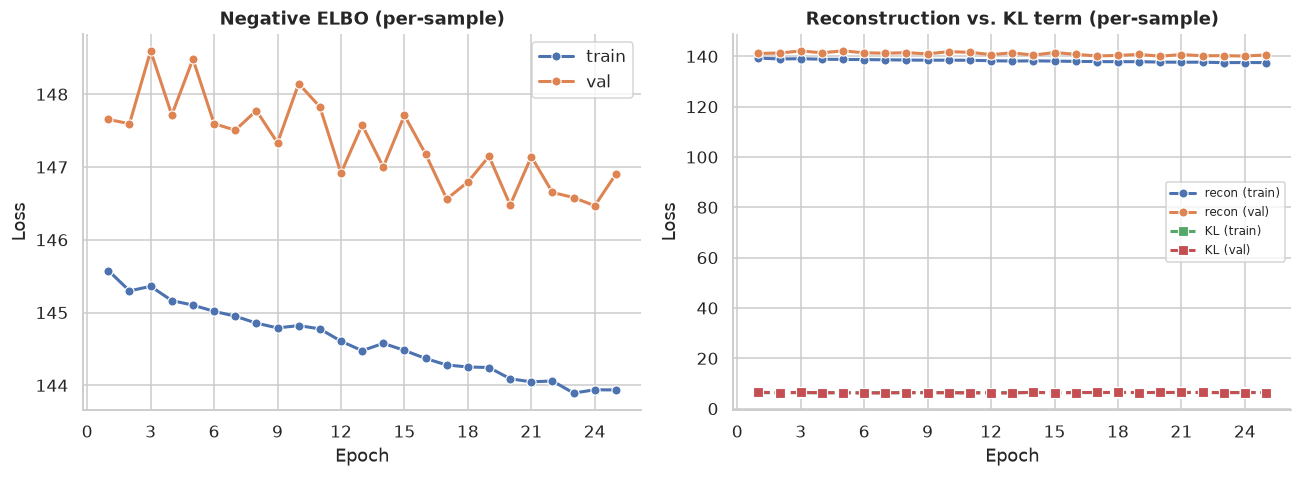

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
epochs_range = list(range(1, len(history["train_elbo"]) + 1))

sns.lineplot(x=epochs_range, y=history["train_elbo"], marker="o", linewidth=2, label="train", ax=axes[0])
sns.lineplot(x=epochs_range, y=history["val_elbo"], marker="o", linewidth=2, label="val", ax=axes[0])
axes[0].set_title("Negative ELBO (per-sample)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].legend(frameon=True)

sns.lineplot(x=epochs_range, y=history["train_recon"], marker="o", linewidth=2, label="recon (train)", ax=axes[1])
sns.lineplot(x=epochs_range, y=history["val_recon"], marker="o", linewidth=2, label="recon (val)", ax=axes[1])
sns.lineplot(x=epochs_range, y=history["train_kl"], marker="s", linewidth=2, linestyle="--", label="KL (train)", ax=axes[1])
sns.lineplot(x=epochs_range, y=history["val_kl"], marker="s", linewidth=2, linestyle="--", label="KL (val)", ax=axes[1])
axes[1].set_title("Reconstruction vs. KL term (per-sample)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].legend(fontsize=8, frameon=True)

sns.despine()
plt.tight_layout(); plt.show()


## 2. Analyzing VAE Performance

### 2(a) Latent Space Visualization

Since `LATENT_DIM = 2`, we can plot $\mu_\phi(x)$ for every test-set image directly in the
2D plane, colored by digit label, with no further dimensionality reduction needed.

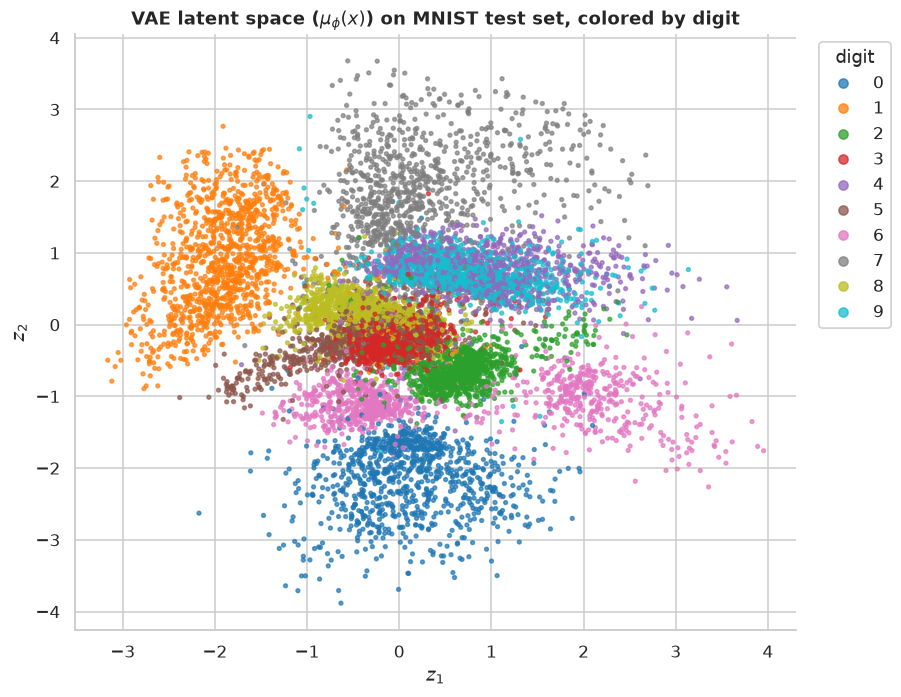

In [13]:
@torch.no_grad()
def collect_latent_means(model, loader):
    model.eval()
    mus, labels = [], []
    for imgs, labs in loader:
        imgs = imgs.to(device)
        mu, _ = model.encode(imgs)
        mus.append(mu.cpu())
        labels.append(labs)
    return torch.cat(mus).numpy(), torch.cat(labels).numpy()

latent_mus, latent_labels = collect_latent_means(vae, test_loader)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
scatter = ax.scatter(latent_mus[:, 0], latent_mus[:, 1], c=latent_labels, cmap="tab10", s=6, alpha=0.7)
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title(r"VAE latent space ($\mu_\phi(x)$) on MNIST test set, colored by digit")
legend = ax.legend(*scatter.legend_elements(), title="digit", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
ax.add_artist(legend)
sns.despine(ax=ax)
plt.tight_layout(); plt.show()


### 2(b) Reconstruction Quality

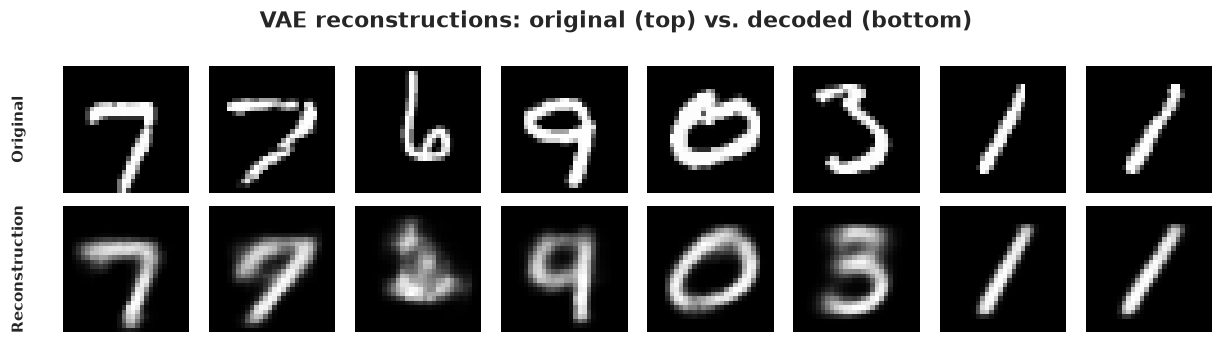

In [14]:
@torch.no_grad()
def show_reconstructions(model, dataset, n=8):
    model.eval()
    idx = np.random.choice(len(dataset), n, replace=False)
    imgs = torch.stack([dataset[i][0] for i in idx]).to(device)

    logits, mu, logvar = model(imgs)
    recon = torch.sigmoid(logits).cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.4 * n, 3.2))
    for i in range(n):
        axes[0, i].imshow(imgs[i, 0].cpu(), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(recon[i, 0], cmap="gray"); axes[1, i].axis("off")

    # row labels (kept visible even though axis("off") hides ticks/spines -- text artists still render)
    axes[0, 0].text(-0.35, 0.5, "Original", transform=axes[0, 0].transAxes,
                     rotation=90, va="center", ha="center", fontsize=10, fontweight="bold")
    axes[1, 0].text(-0.35, 0.5, "Reconstruction", transform=axes[1, 0].transAxes,
                     rotation=90, va="center", ha="center", fontsize=10, fontweight="bold")

    fig.suptitle("VAE reconstructions: original (top) vs. decoded (bottom)", fontweight="bold")
    plt.tight_layout(); plt.show()

show_reconstructions(vae, test_set, n=8)


### 2(c) Generation of New Samples

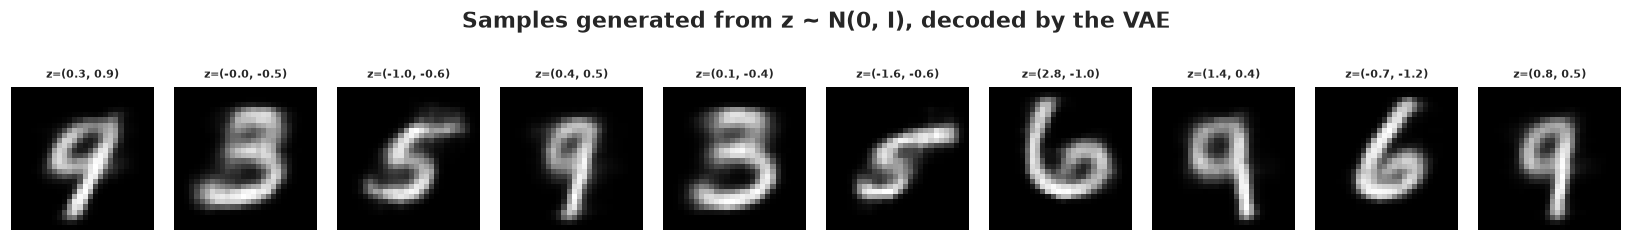

In [15]:
@torch.no_grad()
def generate_samples(model, n=10, latent_dim=2):
    model.eval()
    z = torch.randn(n, latent_dim).to(device)
    logits = model.decode(z)
    samples = torch.sigmoid(logits).cpu()
    return samples, z.cpu()

samples, z_samples = generate_samples(vae, n=10, latent_dim=LATENT_DIM)

fig, axes = plt.subplots(1, 10, figsize=(15, 2.4))
for i in range(10):
    axes[i].imshow(samples[i, 0], cmap="gray")
    axes[i].axis("off")
    # per-sample key: the 2D prior coordinate z that was decoded into this digit
    axes[i].set_title(f"z=({z_samples[i, 0]:.1f}, {z_samples[i, 1]:.1f})", fontsize=7)
fig.suptitle("Samples generated from z ~ N(0, I), decoded by the VAE", fontweight="bold")
plt.tight_layout(); plt.show()


## 3. Comparing with Doersch's VAE Implementation

Carl Doersch's *"Tutorial on Variational Autoencoders"* (2016) includes a reference MNIST VAE
implementation. We compare our design choices against his along the four axes below.

*Answer:* Fill in the comparison after reviewing Doersch's tutorial and code
(`https://github.com/cdoersch/vae_tutorial`) alongside the implementation above:

- **Architecture.** We use a 3-layer convolutional encoder/decoder (`Conv2d`/`ConvTranspose2d` with
  `BatchNorm2d` + `LeakyReLU`, downsampling $28\to14\to7\to4$ and a mirrored upsampling path back to
  $28\times28$), rather than a plain MLP -- the assignment explicitly allows either option. State whether
  Doersch uses an MLP or a convolutional architecture and how many layers/units he uses, and discuss the
  trade-off (a convolutional encoder/decoder exploits the spatial locality of pixel strokes via weight
  sharing, which typically gives sharper reconstructions than a comparably-sized MLP at the cost of a
  slightly more complex architecture).
- **Output distribution and loss.** Doersch treats each pixel intensity as a Bernoulli
  probability and uses a sigmoid cross-entropy (binary cross-entropy) reconstruction loss --
  state whether this matches our implementation above (it does: we use
  `binary_cross_entropy_with_logits` on the decoder's logits, i.e. an implicit Bernoulli output
  distribution per pixel).
- **Latent dimensionality.** We used `LATENT_DIM = 2` specifically so the latent space could be
  visualized directly (Task 2a) without extra dimensionality reduction. Note, and discuss,
  Doersch's observation that VAE performance is fairly insensitive to $z$'s dimensionality over
  a broad range, degrading mainly at the extremes (too small a $z$ cannot encode enough
  information to reconstruct well; too large a $z$ can make the KL term easier to satisfy
  without the encoder using every dimension meaningfully). If time permits, 


In [16]:
# # 1. Zip the weights folder
# !zip -r weights_part4.zip /weights/

# # 2. Download the zip file to your local computer
# from google.colab import files
# files.download('weights_part4.zip')
